# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [91]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [92]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [93]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [94]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [95]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [96]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [97]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [98]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [99]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [100]:
# cantidad de nulos para users
print(users.isna().sum()) # Cantidad de valores nulos
print(users.isna().mean()) # Proporción de valores nulos

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [101]:
# cantidad de nulos para usage
print(usage.isna().sum())   # Cantidad de valores nulos
print(usage.isna().mean())  # Proporción de valores nulos

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?
-----
DIAGNÓSTICO:

'user.city'- contiene 469 nulos, representando el 11.73%, por lo que se recomienda **investigar**

'user.churn_date'- contiene 3534 nulos, representando el 88%, se recomienda revisar la regla de negocio, por el concepto puede representar el número de clientes activos.**investigar**

'usage.date'-contiene 50 nulos,representando el 0.125%, siendo un valor pequeño se podrían eliminar, pero recomiendo validar la importancia de la fecha para el análisis.**investigar**

'usage.duration'- contiene 22,076 nulos, representando el 55.19%, aún no recomendaría eliminar, ya que estos usuarios pueden usar otros servicios diferentes a llamadas, dependiendo el análisis se debe tomar la decisión.**investigar**

'usage.lenght'-contiene 17,896 nulos, representando el 44.74%, aún no recomendaría eliminar, ya que estos porían ser valores de uso de datos, y aquellos nulos en datos, pueden ser valores validos para llamadas.**investigar**


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [102]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id`- Presenta valores entre 10,000 y 13,999 con 4,000 regitros. No observo valores atípicos evidentes.
  
- La columna `age`- Presenta un valor mínimo de -999 y corresponde a un valor sentinel o inválido; este valor distorcionando la media y otros datos; confirmando con el primer, segundo y tercer cuartil (32,47 y 63), como el máximo de 79, representan datos más razonables.

In [103]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


Las columnas id y user_id, presentan rangos consistentes, 'id' va de 1 a 40,000 y 'user_id'de 10,000 a 13,900. No se observan valores inválidos evidentes.
La columna 'duration', presenta valores entre 0 y 120 minutos, la mediana de 3.5 minutos y la media de 5.20. El máximo de 120 miutos es un extremo evidente que requiere investigarse.
La columna 'length' presenta valores entre 0 y 1,490, con una mediana de 50 y un tercer cuartil de 64. El valor de 1,490 es un valor extremo o lejado al comportamiento regular, debe revisarse.
No se observan 'sentinels' evidentes.

In [104]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for columna in columnas_user:
    print(columna)
    print(users[columna].unique())


city
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
plan
['Basico' 'Premium']


- La columna `city`, contiene las categorías "Medellín", "CDMX", "Bogotá","GDL","MTY" y "Cali"; se identifica el valor sentinel o inválido "?", se recomienda remplazar por "NaN"
- La columna `plan` , contiene las categorias "Basico" y "Premium". No se observan valores inválidos.

In [105]:
# explorar columna categórica de usage
usage['type'].unique() # completa el código

array(['call', 'text'], dtype=object)

- La columna `type`, contiene dos categorías "call" y "text", no se observan valores inválidos


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels? - ¿Qué acción tomarías?
   
   'users.age': se detectó el valor -999, que es imposible como edad, es un sentinel de información faltante o inválida. *Acción recomendada*: reemplazar -999 por NaN y posteriormente definir una estrategia de imputación  antes de analizar o segmentar clientes por edad.
  
   'users.city': además de valores NaN, se encontró "?", que no representa una ciudad válida y funciona como sentinel. *Acción recomendada*: reemplazar "?" por NaN para unificar la representación de los valores faltantes.
   'users.plan': únicamente contiene "Basico" y "Premium", son los planes disponibles en plans. *Acción recomendada*: conservar los valores sin modificaciones.
  
   'usage.type': contiene únicamente "call" y "text", son los servicios registrados. *Acción recomendada*: conservar la columna sin modificaciones.
  
    'usage.duration': no se identificaron sentinels evidentes, aunque existen valores desde 0 hasta 120 minutos, y este valor máximo está alejado de la distribución habitual y podría ser un outlier. *Acción recomendada*: no eliminarlo aún; analizar posteriormente la distribución y los valores atípicos para determinar si corresponden a consumos reales.
  
    'usage.length': no presenta sentinels evidentes, pero registra valores desde 0 hasta 1,490, muy por encima del tercer cuartil de 64. *Acción recomendada*: investigar estos valores extremos mediante el análisis de outliers antes de decidir si deben conservarse o tratarse.
 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [106]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') # completa el código

In [107]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce') # completa el código

In [108]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se observan registros correspondientes a 2022 (1,314), 2023 (1,316), 2024 (1,330) y 2026 (40). Los primeros tres años son consistentes con el periodo del dataset; sin embargo, existen 40 fechas de registro en 2026, que representan fechas futuras y están fuera del rango válido, ya que la información de ConnectaTel llega  hasta 2024. *Acción recomendada*: considerar las fechas de 2026 como valores inválidos, convertirlas en NaT y excluirlas o tratarlas como datos faltantes antes de realizar análisis temporales.

In [109]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos) En la columna date de usage se observan 39,950 registros correspondientes al año 2024, por lo que no se identifican años futuros ni fechas fuera del periodo esperado. La diferencia respecto a los 40,000 registros totales corresponde a los 50 valores faltantes (NaT) detectados previamente
- ¿Qué harías con ellas? Conservar las fechas válidas de 2024 y tratar los 50 registros sin fecha como valores faltantes; debido a que representan únicamente el 0.125% del dataset, podrían eliminarse si la fecha es indispensable para el análisis temporal.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [110]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [111]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)


Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [112]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [113]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean())

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [114]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().mean())

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

'duration': presenta 0% de nulos en call y 99.93% en text. Esto indica que la duración corresponde a las llamadas y no aplica a los mensajes.
'length': presenta 99.93% de nulos en call y 0% en text. Esto indica que la longitud corresponde a los mensajes y no aplica a las llamadas.

*Acción recomendada*: mantener estos valores como nulos y no imputarlos, ya que representan valores estructuralmente no aplicables según el tipo de servicio. Imputarlos introduciría datos artificiales y podría distorsionar el análisis.

El pequeño porcentaje de excepciones (≈ 0.07%) es una posible inconsistencia de registro y se sugiere revisarse por separado.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [115]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(
    cant_mensajes=("is_text", "sum"),
    cant_llamadas=("is_call", "sum"),
    cant_minutos_llamada=("duration", "sum")
).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [116]:

# Renombrar columnas

# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [122]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [123]:
# Resumen estadístico de las columnas numéricas
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [124]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

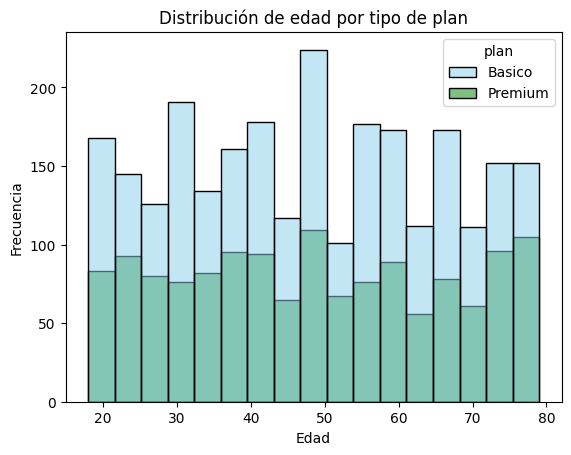

In [125]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue', 'green']
)
plt.title('Distribución de edad por tipo de plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

plt.show()

💡Insights: 
-Las edades de los clientes se distribuyen entre los 18 y 79 años.
-El plan "Básico" y "Premium" están presentes en todo el rango de edades, no se observa una relación clara entre la edad y la elección del plan.
-No se observa un sesgo marcado con respecto a la edad.
-Se oberva una carga más alta de usuarios con Plan Básico entre los 45 y 50 años de edad.


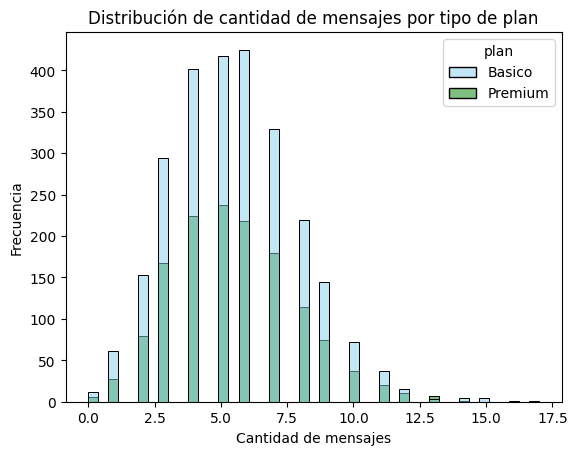

In [126]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Distribución de cantidad de mensajes por tipo de plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')

plt.show()

💡Insights:

- La concentración de usurarios se encuentra aproximadamente entre 3 y 8 mensajes, con un pico alrededor de 5-6 mensajes.
- La distribución presenta un sesgo a la derecha, la frecuencia disminuye conforme aumenta la cantidad de mensajes.
- Los usuarios de plan "Básico" y "Premium" muestran una forma de distribución muy similar, tienen un comportamiento similar.
- En ambos planes, la mayoría de los clientes se concentra en niveles medios de uso, mientras que los usuarios con más de 10 mensajes son menos frecuentes.
- ....

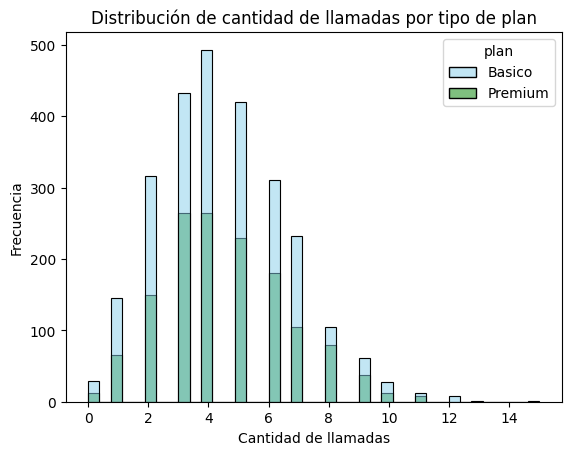

In [127]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Distribución de cantidad de llamadas por tipo de plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')

plt.show()

💡Insights: 
-La amyor parte de los usuarios se concentra entre 2 y 7 llamadas, el pico principal está alrededor de 4 llamadas.
-La distribución está sesgada a la derecha.
-El plan "Básico" presenta mayor frecuencia en casi todos los niveles de llamadas.
-Los usuarios con más llamadas, entre 9 y 10, representan una porción reducida.


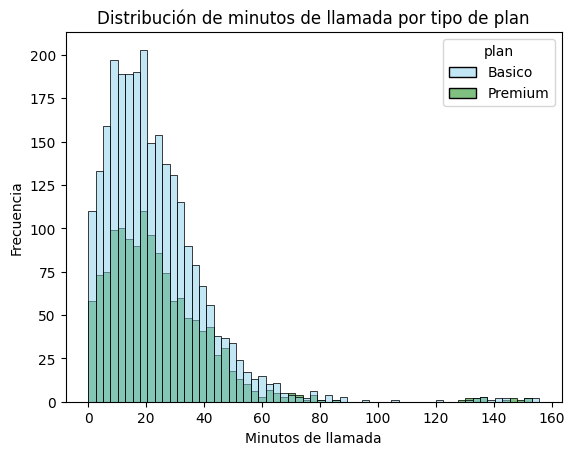

In [128]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Distribución de minutos de llamada por tipo de plan')
plt.xlabel('Minutos de llamada')
plt.ylabel('Frecuencia')

plt.show()

💡Insights:

-La cantidad de minutos por llamada, presenta un sesgo claro a la derecha. La mayoría d elos usuarios se concentra aproximadamente entre 5 y 40 minutos, mientras que algunos clientes alcanzan consumos elevados superiores a 60 minutos e incluso superiores a 140 minutos.
-El Plan "Básico" concnetra mayor uso en casi todo el rango de consumo.
-Los usuarios con consumos muy altos, por encima de 80-100 minutos, sugieren posibles outliers o clientes de uso intensivo que conviene revisar de manera individual.


### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

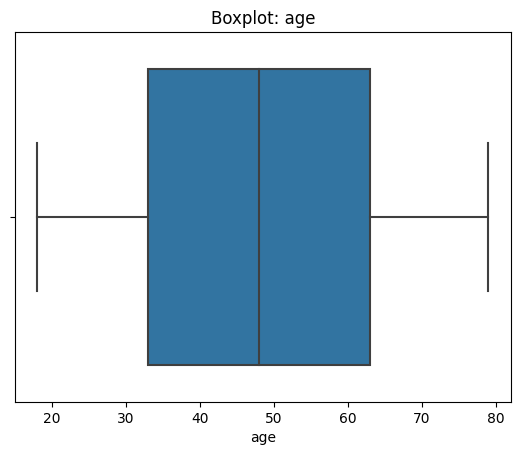

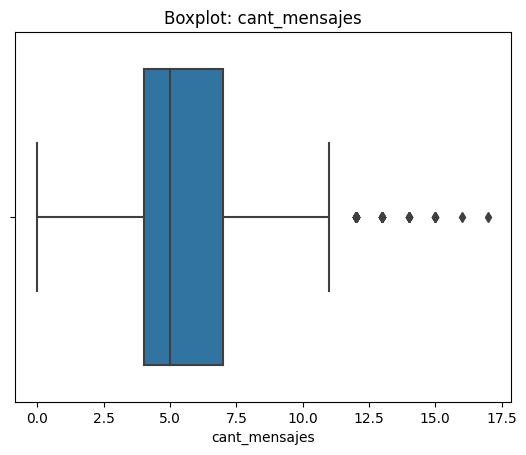

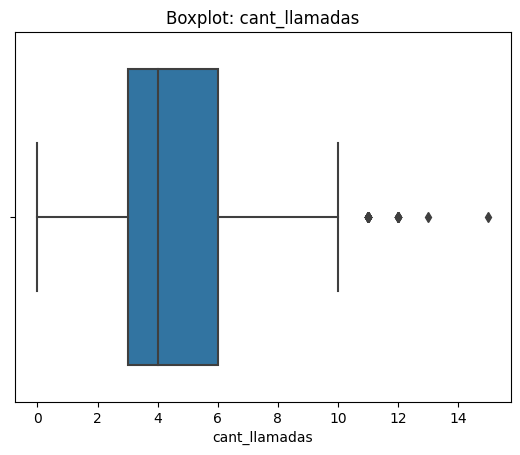

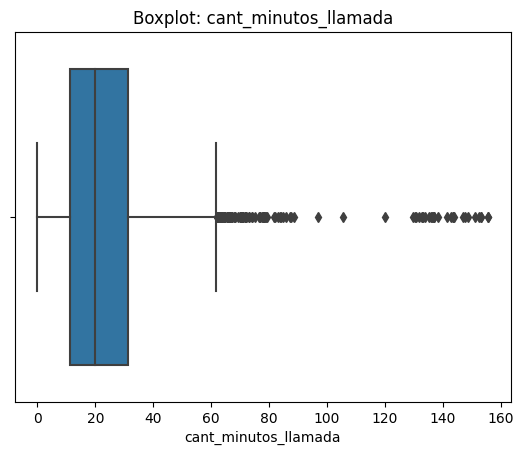

In [129]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 
- Age: No se observan outliers.
- cant_mensajes: Se observan outliers en el límite superior a partir de 12 mensajes.
- cant_llamadas: Se observar outliers superiores, en usuarios que realizan 11 o más llamadas.
- cant_minutos_llamada: Se observar outliers superiores, la mayor parte se concentra en 10 y 30 minutos; mientras que hay valores que superan los 60 minutos, y algunos alcanzan más de 150 minutos.

In [130]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_superior = Q3 + 1.5 * IQR
    
    print(col, ":", limite_superior)

cant_mensajes : 11.5
cant_llamadas : 10.5
cant_minutos_llamada : 61.8575


In [131]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()


,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
Mantener los outliers. El límite superior por IQR es 11.5 y el máximo observado es 17 mensajes. Aunque los valores desde 12 son considerados outliers estadísticos, son totalmente validos como comportamiento real de clientes con mayor uso de mensajería, sin evidencia de error de captura.

- cant_llamadas: mantener o no outliers, porqué?
Mantener los outliers. El límite superior es 10.5 y el máximo es 15 llamadas. La diferencia es moderada y realizar entre 11 y 15 llamadas representa un comportamiento posible de usuarios más activos. Eliminarlos podría sesgar el análisis de clientes de alto consumo.

- cant_minutos_llamada: mantener o no outliers, porqué?
Mantener los outliers. El límite superior es 61.86 minutos y el máximo alcanza 155.69 minutos. Aunque son valores más extremos y generan el sesgo hacia la derecha observado en la distribución, siguen siendo validos para clientes con uso intensivo de llamadas. Deben conservarse porque pueden constituir un segmento relevante para el negocio.
  

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [132]:
# Crear columna grupo_uso
def clasificar_uso(row):
    if pd.isna(row['cant_llamadas']) or pd.isna(row['cant_mensajes']):
        return pd.NA
    elif row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

In [133]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [134]:
# Crear columna grupo_edad
def clasificar_edad(age):
    if age < 30:
        return 'Joven'
    elif age < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile['age'].apply(clasificar_edad)

# Verificar resultado
user_profile[['age', 'grupo_edad']].head()

,age,grupo_edad
0,38.0,Adulto
1,53.0,Adulto
2,57.0,Adulto
3,69.0,Adulto Mayor
4,63.0,Adulto Mayor


In [135]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

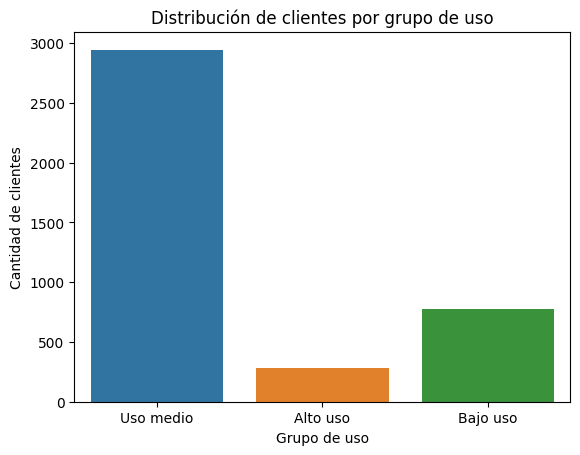

In [136]:
# Visualización de los segmentos por uso
sns.countplot(
    data=user_profile,
    x='grupo_uso'
)

plt.title('Distribución de clientes por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de clientes')

plt.show()

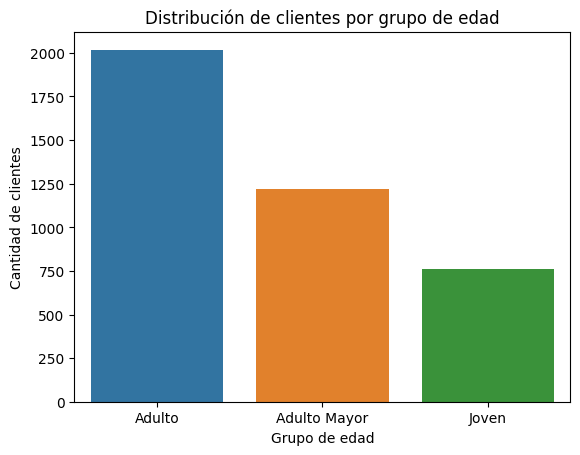

In [137]:
# Visualización de los segmentos por edad
sns.countplot(
    data=user_profile,
    x='grupo_edad'
)

plt.title('Distribución de clientes por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de clientes')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- users.city: originalmente tenía 469 valores nulos (11.73%). Además, se detectó el valor sentinel "?"; al reemplazarlo por NA, la cantidad de ciudades faltantes aumentó a 565 registros (14.13%). Se conservaron como nulos porque no existe información confiable para imputar una ciudad.
  
-users.age: se encontraron valores inválidos de -999, imposibles para una edad. Se reemplazaron por la mediana de las edades válidas, obteniendo después un rango coherente de 18 a 79 años, con mediana de 48 años.

-users.reg_date: se detectaron 40 registros del año 2026 (1% de los 4,000 usuarios). Como el análisis únicamente contempla información hasta 2024, estas fechas se consideraron futuras e inválidas y fueron reemplazadas por NA.

-users.churn_date: presentó 3,534 nulos (88.35%). En este caso no conviene eliminarlos automáticamente, ya que la ausencia de fecha puede representar clientes que no han cancelado el servicio. Por tanto, debe interpretarse según el significado de negocio de la variable.

-usage.date: presentó solamente 50 nulos de 40,000 registros (0.125%). Es una proporción muy pequeña; pueden mantenerse como nulos o excluirse únicamente en análisis que requieran necesariamente la fecha.

-usage.duration y usage.length: inicialmente mostraban 55.19% y 44.74% de nulos, respectivamente. Sin embargo, el análisis demostró que estos faltantes dependen del type: duration corresponde a llamadas y length a mensajes. Por tanto, no representan un problema general de calidad y se conservaron como nulos estructurales.


🔍 **Segmentos por Edad**
-Se identificaron tres grupos: Joven (<30 años), Adulto (30–59 años) y Adulto Mayor (≥60 años).

-Adulto es el segmento predominante, con aproximadamente 2,000 clientes, alrededor de la mitad de la base.

-Adulto Mayor ocupa el segundo lugar, con aproximadamente 1,200 clientes.

-Joven es el grupo menos representado, con aproximadamente 750–800 clientes.

La cartera de ConnectaTel está, por tanto, principalmente concentrada en adultos y adultos mayores. Esto hace que estos grupos sean particularmente relevantes para las estrategias actuales de retención, mientras que la menor participación de jóvenes puede representar una oportunidad de crecimiento. 


📊 **Segmentos por Nivel de Uso**
- Los clientes también se clasificaron en Bajo uso, Uso medio y Alto uso, considerando conjuntamente llamadas y mensajes.

-Uso medio es ampliamente el segmento predominante, con aproximadamente 2,900–3,000 clientes.

-Bajo uso representa aproximadamente 750–800 clientes.

-Alto uso es el grupo más pequeño, con alrededor de 300 clientes.

El comportamiento típico de la cartera es, por tanto, de consumo moderado. No obstante, el segmento de Alto uso, aunque pequeño, puede tener especial importancia comercial debido a su mayor utilización de los servicios.

Segmentos de mayor valor y patrones extremos

Los clientes de Alto uso parecen constituir uno de los segmentos de mayor interés para ConnectaTel, especialmente aquellos que actualmente tienen un plan Básico, ya que podrían ser candidatos para migrar a Premium. Sin embargo, con el análisis realizado hasta ahora no podemos afirmar que sean los clientes de mayor valor económico, porque todavía no hemos calculado ingresos o rentabilidad por cliente.

También se identificaron outliers superiores:

cant_mensajes: límite IQR 11.5, máximo 17 mensajes.
cant_llamadas: límite IQR 10.5, máximo 15 llamadas.
cant_minutos_llamada: límite IQR 61.86, máximo 155.69 minutos.

Estos valores se mantuvieron, ya que son extremos estadísticos pero plausibles desde el punto de vista del negocio. No existe evidencia de que sean errores de captura. Por el contrario, pueden identificar clientes de consumo intensivo, relevantes para estrategias de migración, fidelización y diseño de productos.

➡️ Esto sugiere que ConnectaTel no debería gestionar a toda su cartera con una única estrategia. La combinación de edad + nivel de uso + plan actual permite construir perfiles comerciales más específicos. Los clientes de Uso medio constituyen el mercado principal por volumen, mientras que los de Alto uso pueden ofrecer oportunidades de mayor monetización y los de Bajo uso requieren una propuesta que evite pagar por capacidad que no utilizan.

💡 **Recomendaciones**
- Migración Básico → Premium: identificar clientes de Alto uso que actualmente tienen plan Básico y evaluar campañas de upgrade basadas en su comportamiento real.
  
-Retención Premium: analizar clientes Premium con Bajo uso, porque podrían percibir poco valor en su plan y presentar riesgo de migración o churn.

-Optimizar el plan Básico: dado que el Uso medio domina la cartera, revisar si sus límites y precio corresponden al consumo típico observado.

-Crear ofertas segmentadas: considerar alternativas para bajo, medio y alto consumo, en lugar de depender únicamente de los dos planes actuales.

-Estrategia por edad: mantener acciones de fidelización para Adultos y Adultos Mayores, que concentran la mayor parte de la cartera, y estudiar una propuesta específica para incrementar la penetración entre clientes jóvenes.

-Aprovechar los usuarios intensivos: no eliminar los outliers; utilizarlos como un segmento comercial para evaluar paquetes con mayores beneficios de llamadas y mensajería.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`